<a href="https://colab.research.google.com/github/Mallick223/Mallick223/blob/main/Ml_exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample DataFrame 'df' created:
   Exercise_Hours  Sleep_Hours True_Habit
0             1.0          5.0        Bad
1             2.0          6.0        Bad
2             3.0          7.0       Good
3             4.0          8.0       Good
4             1.5          5.5        Bad


Input Data (Exercise Hours, Sleep Hours vs. True Habit):
Exercise = 1.0, Sleep = 5.0, Habit = Bad
Exercise = 2.0, Sleep = 6.0, Habit = Bad
Exercise = 3.0, Sleep = 7.0, Habit = Good
Exercise = 4.0, Sleep = 8.0, Habit = Good
Exercise = 1.5, Sleep = 5.5, Habit = Bad
Exercise = 2.5, Sleep = 6.5, Habit = Good
Exercise = 3.5, Sleep = 7.5, Habit = Good
Exercise = 0.5, Sleep = 4.5, Habit = Bad
Exercise = 4.5, Sleep = 8.5, Habit = Good
Exercise = 2.0, Sleep = 5.0, Habit = Bad
Exercise = 3.0, Sleep = 6.0, Habit = Good
Exercise = 1.0, Sleep = 7.0, Habit = Bad
Exercise = 4.0, Sleep = 8.0, Habit = Good
Exercise = 2.5, Sleep = 5.5, Habit = Bad
Exercise = 3.5, Sleep = 6.5, Habit = Good

Logistic Regression Results:
  Coe

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


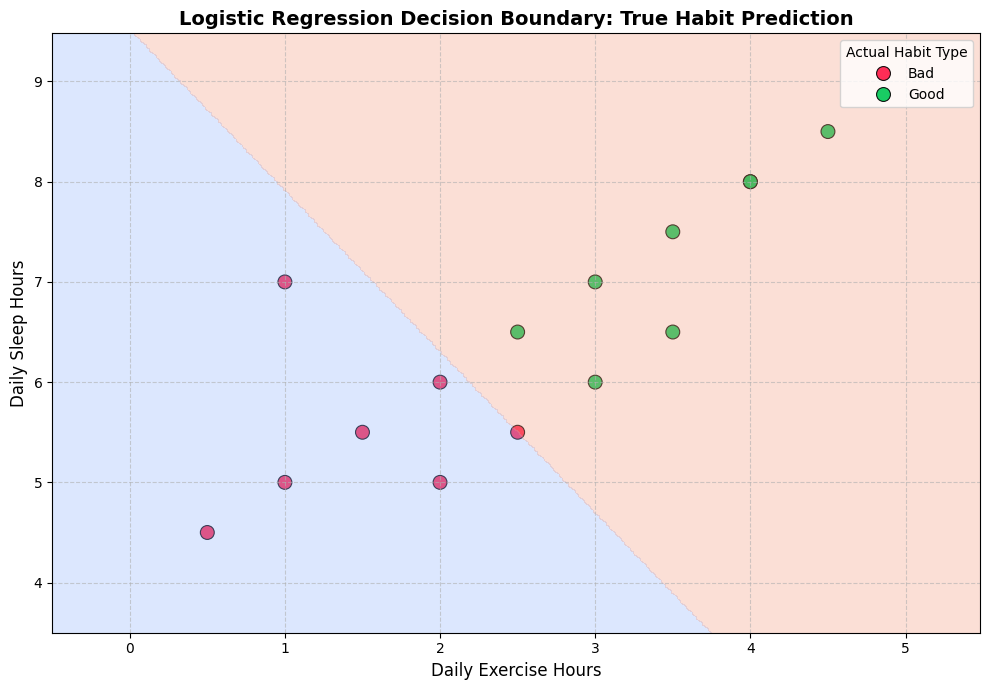


This plot shows the decision boundary learned by the logistic regression model, which classifies habits (Good/Bad) based on Exercise and Sleep Hours. The background colors represent the regions where the model predicts 'Bad' (0) or 'Good' (1) habit, while the scatter points show the actual habits.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# --- Start of fix: Define df --- #
# Create a sample DataFrame 'df' for demonstration purposes
data = {
    'Exercise_Hours': [1, 2, 3, 4, 1.5, 2.5, 3.5, 0.5, 4.5, 2, 3, 1, 4, 2.5, 3.5],
    'Sleep_Hours': [5, 6, 7, 8, 5.5, 6.5, 7.5, 4.5, 8.5, 5, 6, 7, 8, 5.5, 6.5],
    'True_Habit': ['Bad', 'Bad', 'Good', 'Good', 'Bad', 'Good', 'Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good', 'Bad', 'Good']
}
df = pd.DataFrame(data)
print("Sample DataFrame 'df' created:")
print(df.head())
print("\n")
# --- End of fix: Define df --- #


# Prepare features (X) and target (y)
X = df[['Exercise_Hours', 'Sleep_Hours']]
y = df['True_Habit']

# Encode the target variable if it's categorical strings ('Good', 'Bad')
# Logistic Regression expects numerical labels (0 and 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # 'Bad' will be 0, 'Good' will be 1 (alphabetical order)

print("Input Data (Exercise Hours, Sleep Hours vs. True Habit):")
for i in range(len(X)):
    print(f"Exercise = {X['Exercise_Hours'].iloc[i]:.1f}, Sleep = {X['Sleep_Hours'].iloc[i]:.1f}, Habit = {y.iloc[i]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print(f"\nLogistic Regression Results:")
print(f"  Coefficients (Exercise_Hours, Sleep_Hours): {model.coef_[0]}")
print(f"  Intercept: {model.intercept_[0]:.2f}")
print(f"\nClassification Report for Test Set:\n{classification_report(y_test, y_pred, target_names=label_encoder.classes_)}")
print(f"\nConfusion Matrix for Test Set:\n{confusion_matrix(y_test, y_pred)}")

# Plotting the decision boundary
plt.figure(figsize=(10, 7))

# Plot the scatter points, colored by actual habit
sns.scatterplot(x=X['Exercise_Hours'], y=X['Sleep_Hours'], hue=y,
                palette={'Good': '#00c853', 'Bad': '#ff1744'}, s=100, alpha=0.9, marker='o', edgecolor='k', legend='full')

# Create a meshgrid to plot the decision boundary
h = .02
x_min, x_max = X['Exercise_Hours'].min() - 1, X['Exercise_Hours'].max() + 1
y_min, y_max = X['Sleep_Hours'].min() - 1, X['Sleep_Hours'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on the meshgrid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm, levels=[Z.min(), 0.5, Z.max()])

plt.title('Logistic Regression Decision Boundary: True Habit Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Daily Exercise Hours', fontsize=12)
plt.ylabel('Daily Sleep Hours', fontsize=12)
plt.legend(title='Actual Habit Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nThis plot shows the decision boundary learned by the logistic regression model, which classifies habits (Good/Bad) based on Exercise and Sleep Hours. The background colors represent the regions where the model predicts 'Bad' (0) or 'Good' (1) habit, while the scatter points show the actual habits.")